In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/soybean-seedsclassification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 610M/610M [00:02<00:00, 244MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1):
['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']


In [ ]:
import os

# Use 'path' directly as classes are located here
data_path = path

# List soybean class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Soybean classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Soybean classes found: ['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1) ---
Found 5513 images. Displaying 6 sample images:


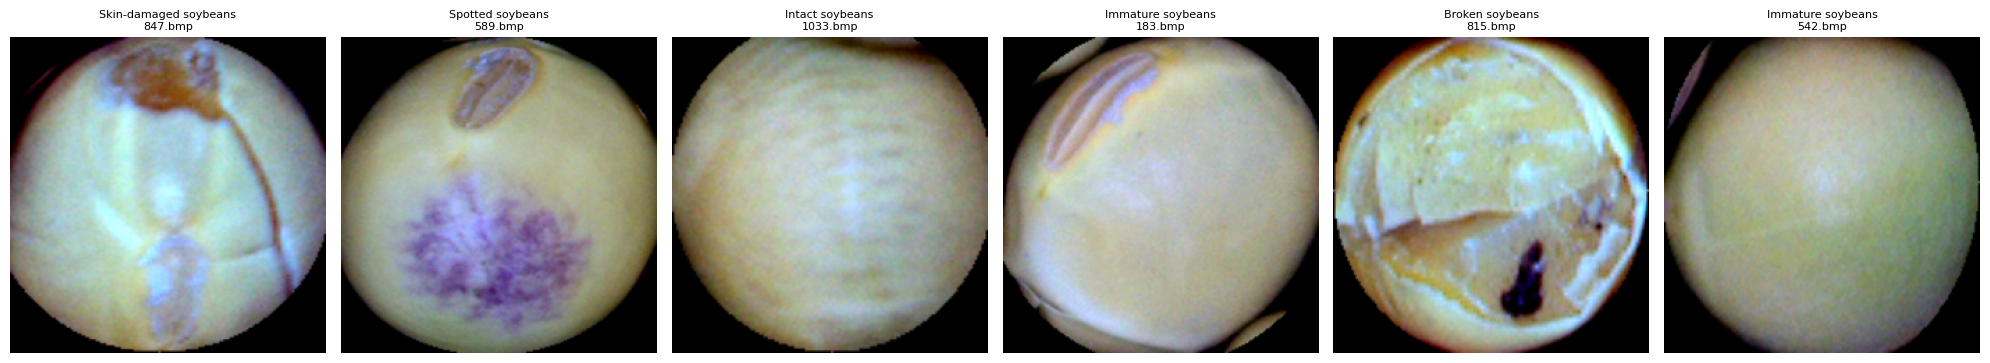

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct path identified in the previous cell
data_path = path
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Define the output folder
output_folder = "soybean_split"

# Split with a ratio of 0.8 for train and 0.2 for val (test)
# seed=1337 ensures reproducibility
splitfolders.ratio(data_path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Dataset successfully split! Check the '{output_folder}' directory.")

Copying files: 5513 files [00:07, 733.95 files/s]

Dataset successfully split! Check the 'soybean_split' directory.


In [ ]:
# Verify the split results
for split in ['train', 'val']:
    print(f"\n--- {split.upper()} set ---")
    split_path = os.path.join(output_folder, split)
    for class_name in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"{class_name}: {count} images")


--- TRAIN set ---
Spotted soybeans: 846 images
Intact soybeans: 960 images
Immature soybeans: 900 images
Skin-damaged soybeans: 901 images
Broken soybeans: 801 images

--- VAL set ---
Spotted soybeans: 212 images
Intact soybeans: 241 images
Immature soybeans: 225 images
Skin-damaged soybeans: 226 images
Broken soybeans: 201 images


In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cpu


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets from the split folder
image_datasets = {x: datasets.ImageFolder(os.path.join(output_folder, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Build DenseNet model
model = models.densenet121(weights='IMAGENET1K_V1')
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 197MB/s]


In [ ]:
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

model, history = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 0/9
----------
train Loss: 0.5346 Acc: 0.8047
val Loss: 0.4933 Acc: 0.8416
Epoch 1/9
----------
train Loss: 0.3582 Acc: 0.8721
val Loss: 0.3538 Acc: 0.8670
Epoch 2/9
----------
train Loss: 0.3289 Acc: 0.8832
val Loss: 0.3171 Acc: 0.8742
Epoch 3/9
----------
train Loss: 0.2694 Acc: 0.9004
val Loss: 0.3986 Acc: 0.8778
Epoch 4/9
----------
train Loss: 0.2598 Acc: 0.9074
val Loss: 0.3460 Acc: 0.8833
Epoch 5/9
----------
train Loss: 0.2068 Acc: 0.9242
val Loss: 0.3211 Acc: 0.8932
Epoch 6/9
----------
train Loss: 0.2081 Acc: 0.9242
val Loss: 0.2746 Acc: 0.9122
Epoch 7/9
----------
train Loss: 0.1975 Acc: 0.9276
val Loss: 0.2381 Acc: 0.9249
Epoch 8/9
----------
train Loss: 0.1809 Acc: 0.9344
val Loss: 0.2311 Acc: 0.9222
Epoch 9/9
----------
train Loss: 0.1430 Acc: 0.9446
val Loss: 0.3176 Acc: 0.9023
Training complete in 272m 10s
Best val Acc: 0.924887


In [ ]:
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Best Validation Accuracy achieved: {max(history['val_acc']):.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9446
Final Validation Accuracy: 0.9023
Best Validation Accuracy achieved: 0.9249


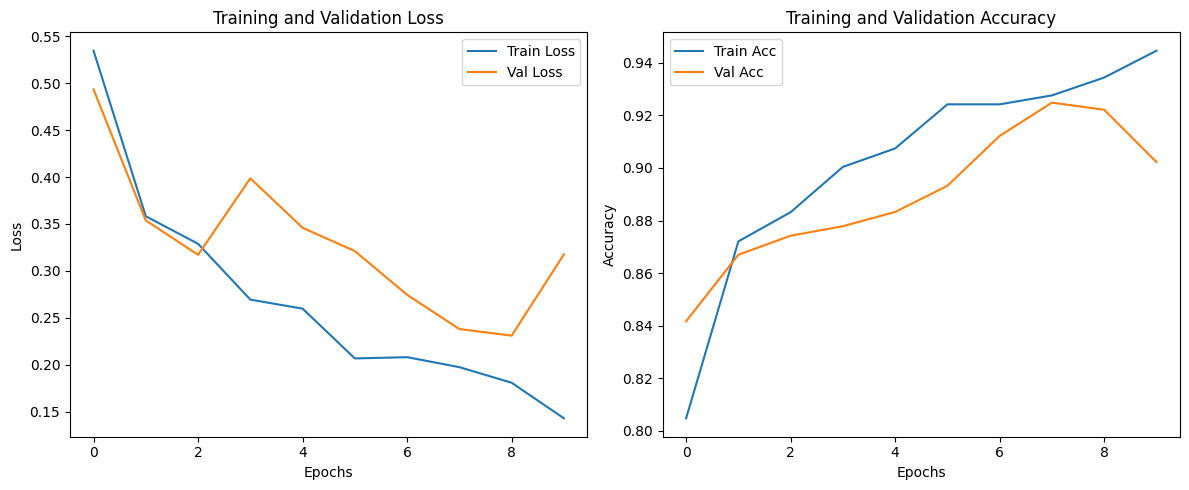

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()